In [23]:
import os
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

# ── resolve paths regardless of cwd (mirrors ../2026_27_priors.ipynb) ──────
_here = Path.cwd()
if not (_here / 'value_analysis.ipynb').exists():
    for _c in [_here / 'value',
               _here / 'priors' / 'value',
               _here / 'premier_league' / 'priors' / 'value',
               _here / 'non_penalty_bayes' / 'premier_league' / 'priors' / 'value',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league' / 'priors' / 'value']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = NOTEBOOK_DIR.parents[6]
DB_PATH      = REPO_ROOT / 'infra' / 'data' / 'db' / 'priors.db'

# CPI deflator machinery + salary team-name map already live in this folder's
# adjustment/regression scripts -- import rather than re-deriving so there's
# one source of truth for the CPI series (adjust_salaries_for_inflation.py).
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from adjust_salaries_for_inflation import TARGET_SEASON, season_avg_cpi
from salary_and_champ_regressions import NAME_MAP_SALARY

with sqlite3.connect(DB_PATH) as conn:
    raw_results     = pd.read_sql('SELECT * FROM raw_results', conn)
    squad_values     = pd.read_sql('SELECT * FROM transfermarkt_squad_values', conn)
    player_values    = pd.read_sql('SELECT * FROM transfermarkt_player_values', conn)
    salaries         = pd.read_sql('SELECT * FROM prem_salaries_raw', conn)

# ── inflation-adjust all three money series into constant TARGET_SEASON terms ──
# (squad_value_eur / gross_unadjusted / value_eur are nominal -- comparing a
#  2015-16 figure directly to a 2025-26 one overstates how much "bigger"
#  recent spending is. squad_value_eur & value_eur are EUR, gross_unadjusted
#  (wage bill) is GBP -- each stays in its own currency, just rebased to
#  constant TARGET_SEASON purchasing power.)
def add_real_terms(df: pd.DataFrame, nominal_col: str, real_col: str) -> pd.DataFrame:
    df = df.copy()
    cpi_by_season = {s: season_avg_cpi(s) for s in df['season'].unique()}
    target_cpi = season_avg_cpi(TARGET_SEASON)
    df['cpi_index'] = df['season'].map(cpi_by_season)
    df['deflator']  = target_cpi / df['cpi_index']
    df[real_col]    = df[nominal_col] * df['deflator']
    return df

squad_values  = add_real_terms(squad_values, 'squad_value_eur', 'squad_value_real')
salaries      = add_real_terms(salaries, 'gross_unadjusted', 'gross_real')
player_values = add_real_terms(player_values, 'value_eur', 'value_real')

# ── PL squad transfer values per season (dataspan: 2015-2016 .. 2026-2027) ──
squad_values = squad_values.sort_values(['season', 'team']).reset_index(drop=True)
DATASPAN_SEASONS = sorted(squad_values['season'].unique())

# ── per-player age & value, same dataspan/team-naming as squad_values ──────
player_values = player_values.sort_values(['season', 'team', 'value_eur'], ascending=[True, True, False]).reset_index(drop=True)

# ── wage bills: prem_salaries_raw team names -> raw_results/transfermarkt convention ──
salaries['team'] = salaries['team_name'].replace(NAME_MAP_SALARY)
salaries = salaries.sort_values(['season', 'team']).reset_index(drop=True)

# ── PL results -> per-team-season goals scored/conceded and league points ──
# (raw_results only has played fixtures, so this naturally stops at the last
#  completed season -- 2026-2027 has squad values but no results yet)
pl = raw_results[raw_results['division'] == 'Premier_League'].copy()

home = pl.rename(columns={'home_team': 'team', 'away_team': 'opponent',
                           'home_goals': 'gf', 'away_goals': 'ga'})
home['points'] = np.select([home['gf'] > home['ga'], home['gf'] == home['ga']], [3, 1], default=0)

away = pl.rename(columns={'away_team': 'team', 'home_team': 'opponent',
                           'away_goals': 'gf', 'home_goals': 'ga'})
away['points'] = np.select([away['gf'] > away['ga'], away['gf'] == away['ga']], [3, 1], default=0)

team_games = pd.concat([
    home[['season', 'team', 'gf', 'ga', 'points']],
    away[['season', 'team', 'gf', 'ga', 'points']],
], ignore_index=True)

pl_results = team_games.groupby(['season', 'team']).agg(
    games=('gf', 'size'),
    goals_scored=('gf', 'sum'),
    goals_conceded=('ga', 'sum'),
    points=('points', 'sum'),
).reset_index()
pl_results['goal_diff'] = pl_results['goals_scored'] - pl_results['goals_conceded']
pl_results = pl_results[pl_results['season'].isin(DATASPAN_SEASONS)].sort_values(['season', 'points'], ascending=[True, False]).reset_index(drop=True)

# ── squad summaries per season: value-table totals + age/value stats from player-level data ──
player_agg = player_values.groupby(['season', 'team']).agg(
    n_players_listed=('player', 'size'),
    mean_age=('age', 'mean'),
    median_age=('age', 'median'),
    mean_player_value_eur=('value_eur', 'mean'),
    median_player_value_eur=('value_eur', 'median'),
    max_player_value_eur=('value_eur', 'max'),
).reset_index()

squad_summary = squad_values.merge(player_agg, on=['season', 'team'], how='left')
squad_summary['mean_age'] = squad_summary['mean_age'].round(1)

# ── single panel: squad value/age summary + wage bill + that season's PL results ──
panel = squad_summary.merge(pl_results, on=['season', 'team'], how='left')
panel = panel.merge(
    salaries[['season', 'team', 'gross_unadjusted', 'gross_real']].rename(
        columns={'gross_unadjusted': 'wage_bill_gbp', 'gross_real': 'wage_bill_real'}),
    on=['season', 'team'], how='left',
)

print(f'raw_results:     {len(raw_results):,} rows')
print(f'squad_values:    {len(squad_values):,} rows  ({len(DATASPAN_SEASONS)} seasons, {squad_values["team"].nunique()} distinct teams)')
print(f'player_values:   {len(player_values):,} rows')
print(f'salaries:        {len(salaries):,} rows  ({salaries["season"].nunique()} seasons, target={TARGET_SEASON} real terms)')
print(f'pl_results:      {len(pl_results):,} team-seasons (goals + points)')
print(f'squad_summary:   {len(squad_summary):,} team-seasons')
print(f'panel:           {len(panel):,} team-seasons ({panel["points"].isna().sum()} without results, i.e. {sorted(panel.loc[panel["points"].isna(), "season"].unique())}; {panel["wage_bill_gbp"].isna().sum()} without wage data)')
panel.head(10)


raw_results:     30,920 rows
squad_values:    240 rows  (12 seasons, 35 distinct teams)
player_values:   8,388 rows
salaries:        220 rows  (11 seasons, target=2025-2026 real terms)
pl_results:      220 team-seasons (goals + points)
squad_summary:   240 team-seasons
panel:           240 team-seasons (20 without results, i.e. ['2026-2027']; 20 without wage data)


,team,season,squad_value_eur,n_players,cpi_index,deflator,squad_value_real,n_players_listed,mean_age,median_age,mean_player_value_eur,median_player_value_eur,max_player_value_eur,games,goals_scored,goals_conceded,points,goal_diff,wage_bill_gbp,wage_bill_real
0,Arsenal,2015-2016,457850000.0,38,100.15,1.400999,6.414472e+08,38,25.1,24.5,1.204868e+07,8500000.0,55000000.0,38.0,65.0,36.0,71.0,29.0,96700000.0,1.354766e+08
1,Aston Villa,2015-2016,117950000.0,34,100.15,1.400999,1.652478e+08,34,26.2,26.0,3.469118e+06,3000000.0,10000000.0,38.0,27.0,76.0,17.0,-49.0,37000000.0,5.183694e+07
2,Bournemouth,2015-2016,99900000.0,39,100.15,1.400999,1.399598e+08,39,26.6,26.0,2.561538e+06,1500000.0,15000000.0,38.0,45.0,67.0,42.0,-22.0,26600000.0,3.726656e+07
3,Chelsea,2015-2016,553500000.0,34,100.15,1.400999,7.754527e+08,34,25.7,26.0,1.627941e+07,11000000.0,65000000.0,38.0,59.0,53.0,50.0,6.0,100000000.0,1.400999e+08
4,Crystal Palace,2015-2016,135700000.0,33,100.15,1.400999,1.901155e+08,33,27.7,28.0,4.112121e+06,3500000.0,18000000.0,38.0,39.0,51.0,42.0,-12.0,55600000.0,7.789552e+07
5,Everton,2015-2016,249850000.0,33,100.15,1.400999,3.500395e+08,33,26.8,26.0,7.571212e+06,3000000.0,40000000.0,38.0,59.0,55.0,47.0,4.0,55400000.0,7.761532e+07
6,Leicester,2015-2016,161100000.0,31,100.15,1.400999,2.257009e+08,31,27.7,28.0,5.196774e+06,4000000.0,20000000.0,38.0,68.0,36.0,81.0,32.0,38400000.0,5.379834e+07
7,Liverpool,2015-2016,375250000.0,39,100.15,1.400999,5.257247e+08,39,23.9,23.0,9.621795e+06,7000000.0,35000000.0,38.0,63.0,50.0,60.0,13.0,93600000.0,1.311335e+08
8,Man City,2015-2016,499350000.0,28,100.15,1.400999,6.995886e+08,28,27.7,28.5,1.783393e+07,15000000.0,60000000.0,38.0,71.0,41.0,66.0,30.0,127000000.0,1.779268e+08
9,Man United,2015-2016,439850000.0,34,100.15,1.400999,6.162292e+08,34,24.9,24.5,1.293676e+07,9000000.0,40000000.0,38.0,49.0,35.0,66.0,14.0,123200000.0,1.726030e+08


In [24]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

OUT_DIR = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# ── Fonts (same system as postmortem_v2.ipynb / viz/pl_scatter.py) ─────────
for _path in ['/Users/admin/Library/Fonts/Roboto-Regular.ttf',
              '/Users/admin/Library/Fonts/Roboto-Bold.ttf']:
    try:
        fm.fontManager.addfont(_path)
    except Exception:
        pass

# ── Shared palette — datawrapper-style house colours (postmortem_v2.ipynb) ─
C_XG    = '#2a78d6'
C_GOALS = '#eb6834'
C_PRED  = '#1baf7a'
C_OVER  = '#e34948'
C_UNDER = '#2a78d6'
C_GRID  = '#eeeeee'
C_AXIS  = '#cccccc'
C_MUTED = '#888888'
C_INK   = '#1a1a1a'
C_INK2  = '#666666'

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'Roboto',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK2,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})


def _dw_style(ax, grid_axis='both'):
    """Datawrapper-style axis dressing: hide top/right spines, faint grid,
    no tick marks, muted tick labels — matches postmortem_v2.ipynb."""
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(C_AXIS)
    ax.spines['bottom'].set_color(C_AXIS)
    ax.tick_params(length=0, colors=C_INK2)
    ax.grid(axis=grid_axis, color=C_GRID, linewidth=0.8)
    ax.set_axisbelow(True)


def _dw_title(ax, title, subtitle=None, y=1.12, dy=0.055, size=13, sub_size=9.5):
    """Left-aligned bold title + grey subtitle sitting above the axes."""
    ax.text(0, y, title, transform=ax.transAxes,
            fontsize=size, fontweight='bold', color=C_INK, va='bottom', ha='left')
    if subtitle:
        ax.text(0, y - dy, subtitle, transform=ax.transAxes,
                fontsize=sub_size, color=C_MUTED, va='bottom', ha='left')


/var/folders/7c/dkh0wxt56g39m3h9nmfq79mc0000gn/T/ipykernel_68681/551126451.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8.5, frameon=False, loc='upper left' if y_col != 'goals_conceded' else 'lower left',


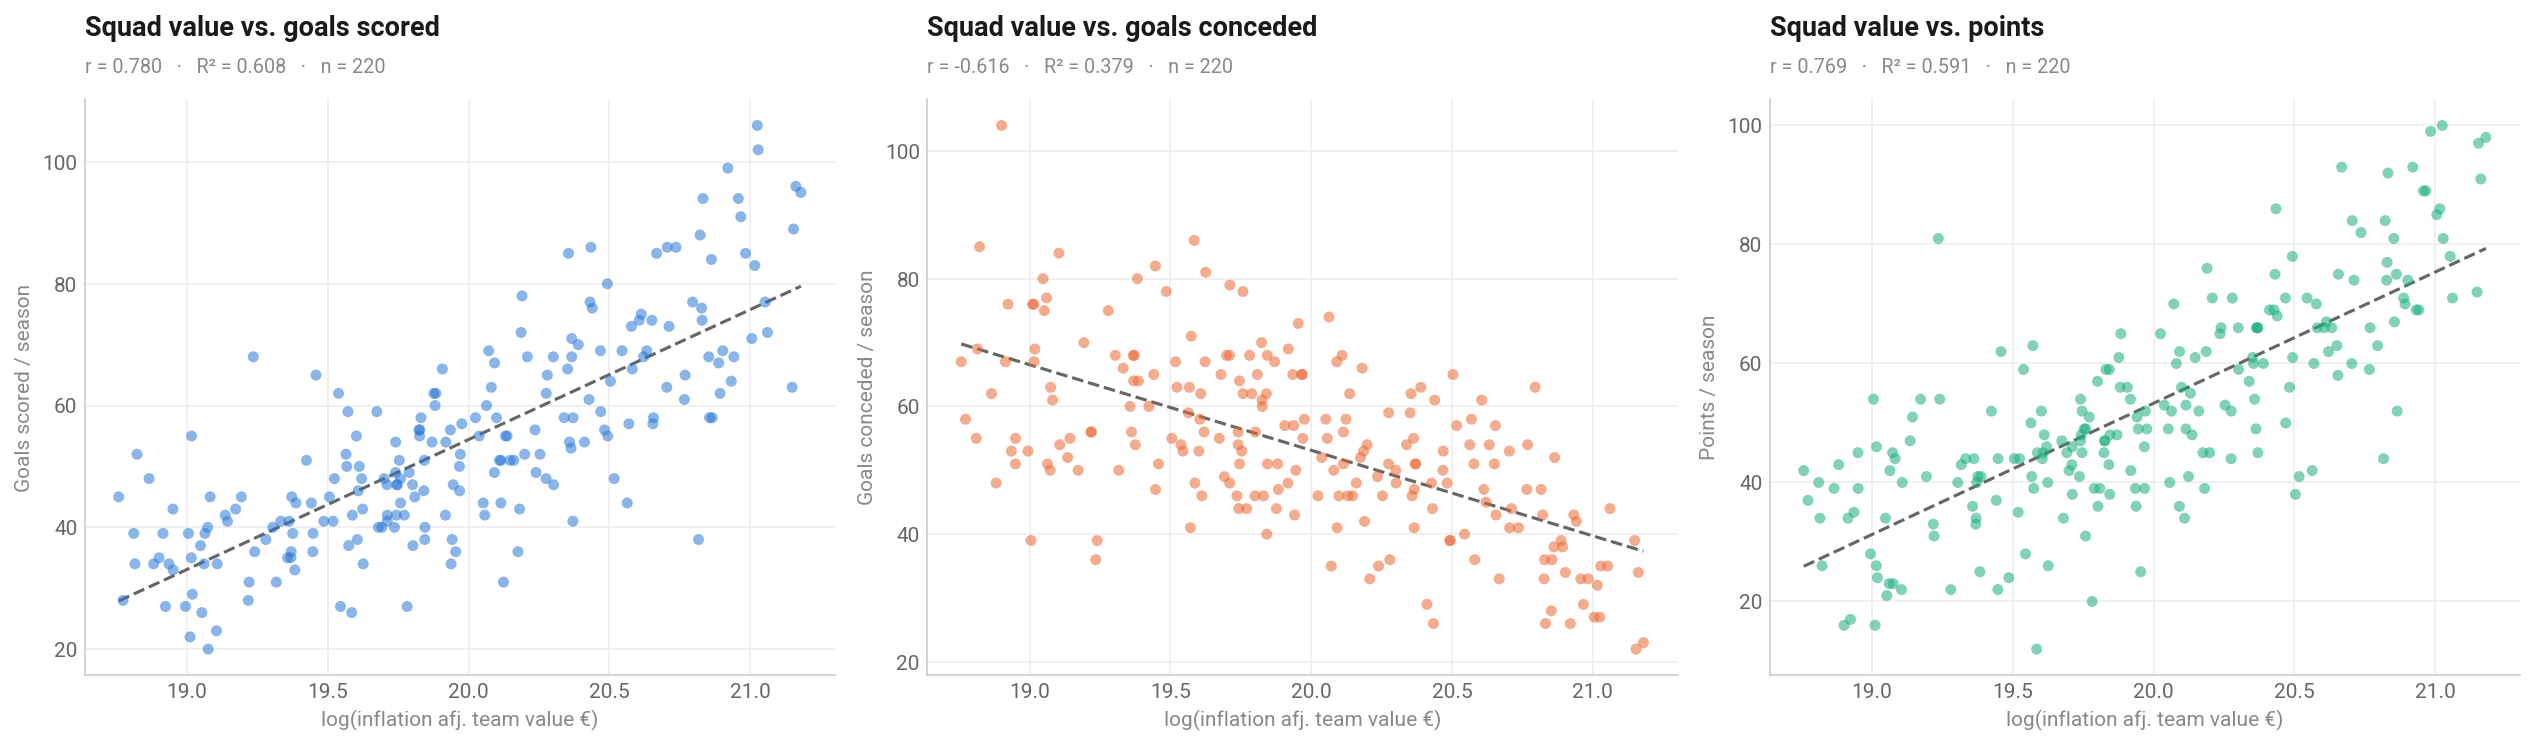

In [25]:
import statsmodels.api as sm

# Played seasons only (2026-2027 has squad values but no PL results yet)
reg_df = panel.dropna(subset=['points']).copy()
reg_df['log_value'] = np.log(reg_df['squad_value_real'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

panels = [
    (axes[0], 'goals_scored',   'Squad value vs. goals scored',   'Goals scored / season',   C_XG),
    (axes[1], 'goals_conceded', 'Squad value vs. goals conceded', 'Goals conceded / season', C_GOALS),
    (axes[2], 'points',         'Squad value vs. points',         'Points / season',         C_PRED),
]

for ax, y_col, title, ylabel, color in panels:
    x = reg_df['log_value']
    y = reg_df[y_col]

    model = sm.OLS(y, sm.add_constant(x)).fit()
    r = np.corrcoef(x, y)[0, 1]

    ax.scatter(x, y, s=28, alpha=0.55, color=color, edgecolors='none', zorder=3)
    xs = np.linspace(x.min(), x.max(), 100)
    pred = model.predict(sm.add_constant(xs, has_constant='add'))
    ax.plot(xs, pred, '--', color=C_INK2, lw=1.5, zorder=2,)

    _dw_title(ax, title, f'r = {r:.3f}   ·   R² = {model.rsquared:.3f}   ·   n = {len(reg_df)}', y=1.10, dy=0.06)
    ax.set_xlabel(f'log(inflation afj. team value €)', fontsize=10, color=C_MUTED)
    ax.set_ylabel(ylabel, fontsize=10, color=C_MUTED)
    ax.legend(fontsize=8.5, frameon=False, loc='upper left' if y_col != 'goals_conceded' else 'lower left',
              labelcolor=C_INK2)
    _dw_style(ax)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / 'squad_value_regressions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


/var/folders/7c/dkh0wxt56g39m3h9nmfq79mc0000gn/T/ipykernel_68681/1079177218.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8.5, frameon=False, loc='upper left' if y_col != 'goals_conceded' else 'lower left',


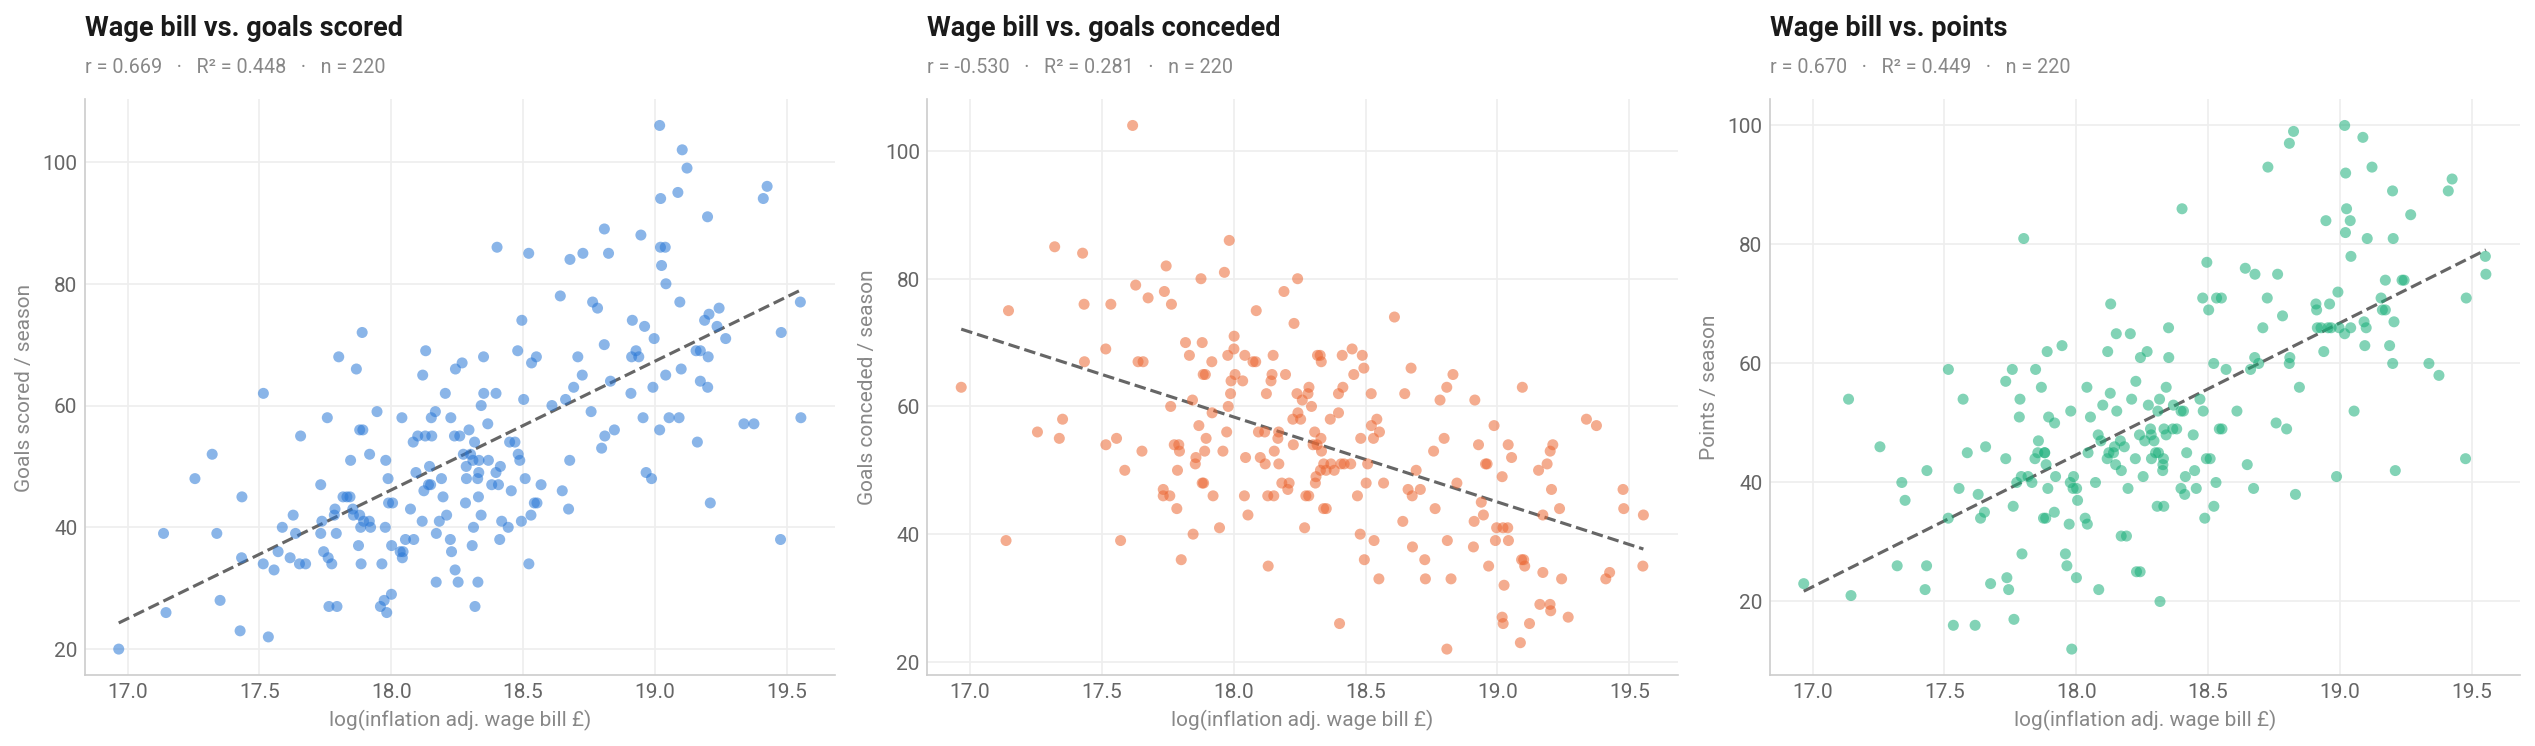

In [26]:
wage_reg_df = panel.dropna(subset=['points', 'wage_bill_gbp']).copy()
wage_reg_df['log_wage'] = np.log(wage_reg_df['wage_bill_real'])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

panels = [
    (axes[0], 'goals_scored',   'Wage bill vs. goals scored',   'Goals scored / season',   C_XG),
    (axes[1], 'goals_conceded', 'Wage bill vs. goals conceded', 'Goals conceded / season', C_GOALS),
    (axes[2], 'points',         'Wage bill vs. points',         'Points / season',         C_PRED),
]

for ax, y_col, title, ylabel, color in panels:
    x = wage_reg_df['log_wage']
    y = wage_reg_df[y_col]

    model = sm.OLS(y, sm.add_constant(x)).fit()
    r = np.corrcoef(x, y)[0, 1]

    ax.scatter(x, y, s=28, alpha=0.55, color=color, edgecolors='none', zorder=3)
    xs = np.linspace(x.min(), x.max(), 100)
    pred = model.predict(sm.add_constant(xs, has_constant='add'))
    ax.plot(xs, pred, '--', color=C_INK2, lw=1.5, zorder=2,)

    _dw_title(ax, title, f'r = {r:.3f}   ·   R² = {model.rsquared:.3f}   ·   n = {len(reg_df)}', y=1.10, dy=0.06)
    ax.set_xlabel(f'log(inflation adj. wage bill £)', fontsize=10, color=C_MUTED)
    ax.set_ylabel(ylabel, fontsize=10, color=C_MUTED)
    ax.legend(fontsize=8.5, frameon=False, loc='upper left' if y_col != 'goals_conceded' else 'lower left',
              labelcolor=C_INK2)
    _dw_style(ax)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / 'wage_bill_regressions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


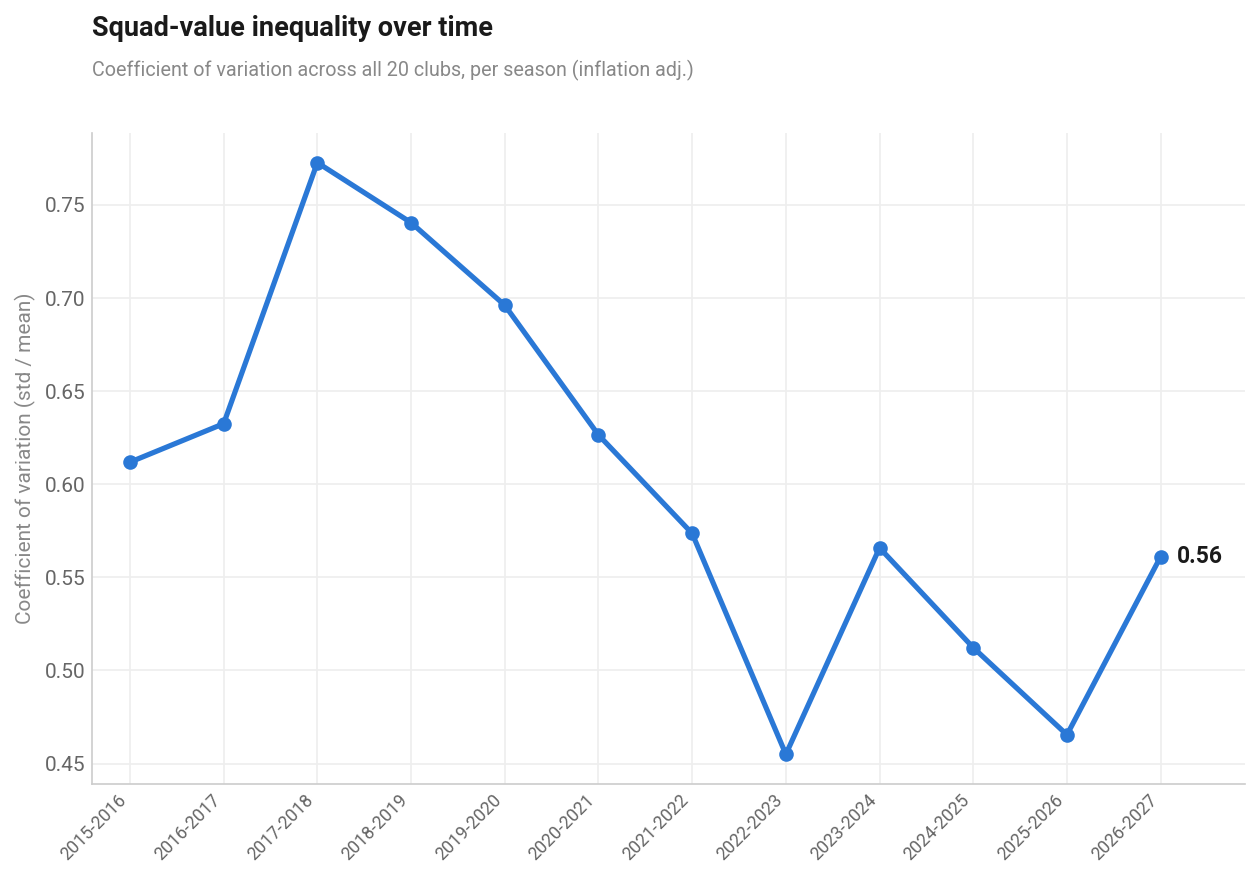

Squad value CV:        0.61 -> 0.56   r=-0.762 p=0.004  TIGHTENING
Squad value P90/P10:   4.09x -> 4.45x   r=-0.441 p=0.152  suggestive


In [27]:
from scipy.stats import spearmanr

# Dispersion per season, real (inflation-adjusted) terms.
# CV (std/mean) is the primary metric -- it uses all 20 teams. The 90th/10th
# percentile ratio is included too but is unreliable at n=20/season: with
# only 20 points, p10 and p90 are effectively just "the 2nd-smallest" and
# "the 2nd-largest" team that year, so the ratio swings on single outliers
# rather than the shape of the whole distribution.
# Includes 2026-2027 (already known preseason).
def spread_by_season(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    g = df.groupby('season')[value_col]
    out = pd.DataFrame({
        'mean': g.mean(), 'std': g.std(),
        'p10': g.quantile(0.10), 'p90': g.quantile(0.90),
    }).reset_index()
    out['cv'] = out['std'] / out['mean']
    out['p90_p10_ratio'] = out['p90'] / out['p10']
    return out.sort_values('season').reset_index(drop=True)

squad_spread = spread_by_season(squad_values, 'squad_value_real')


def cv_chart(ax, spread_df, color, title, subtitle):
    x = np.arange(len(spread_df))
    y = spread_df['cv'].values
    ax.plot(x, y, '-o', color=color, lw=2.5, markersize=6, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(spread_df['season'], rotation=45, ha='right', fontsize=8.5)
    ax.annotate(f'{y[-1]:.2f}', (x[-1], y[-1]), textcoords='offset points',
                xytext=(8, 0), ha='left', va='center', fontsize=11, fontweight='bold', color=C_INK)
    _dw_title(ax, title, subtitle, y=1.14, dy=0.06)
    ax.set_ylabel('Coefficient of variation (std / mean)', fontsize=10, color=C_MUTED)
    ax.set_xlim(x[0] - 0.4, x[-1] + 0.9)
    _dw_style(ax, grid_axis='y')


fig, ax = plt.subplots(figsize=(8.5, 6))
cv_chart(ax, squad_spread, C_XG,
         'Squad-value inequality over time', 'Coefficient of variation across all 20 clubs, per season (inflation adj.)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'value_inequality_over_time.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

season_idx = np.arange(len(squad_spread))
cv_r, cv_p = spearmanr(season_idx, squad_spread['cv'])
pr_r, pr_p = spearmanr(season_idx, squad_spread['p90_p10_ratio'])
cv_verdict = 'TIGHTENING' if (cv_r < 0 and cv_p < 0.05) else ('suggestive' if cv_r < 0 else 'not tightening')
pr_verdict = 'TIGHTENING' if (pr_r < 0 and pr_p < 0.05) else ('suggestive' if pr_r < 0 else 'not tightening')
print(f'Squad value CV:        {squad_spread["cv"].iloc[0]:.2f} -> {squad_spread["cv"].iloc[-1]:.2f}   '
      f'r={cv_r:+.3f} p={cv_p:.3f}  {cv_verdict}')
print(f'Squad value P90/P10:   {squad_spread["p90_p10_ratio"].iloc[0]:.2f}x -> {squad_spread["p90_p10_ratio"].iloc[-1]:.2f}x   '
      f'r={pr_r:+.3f} p={pr_p:.3f}  {pr_verdict}')


log(value) ~ age + age^2   n=8388  R^2=0.229  peak age=26.9
     const: -6.1602  (se=0.4394, p=0.000)
       age:  1.6731  (se=0.0335, p=0.000)
    age_sq: -0.0311  (se=0.0006, p=0.000)

Merged squad_value_age_adjusted into panel (240 team-seasons)


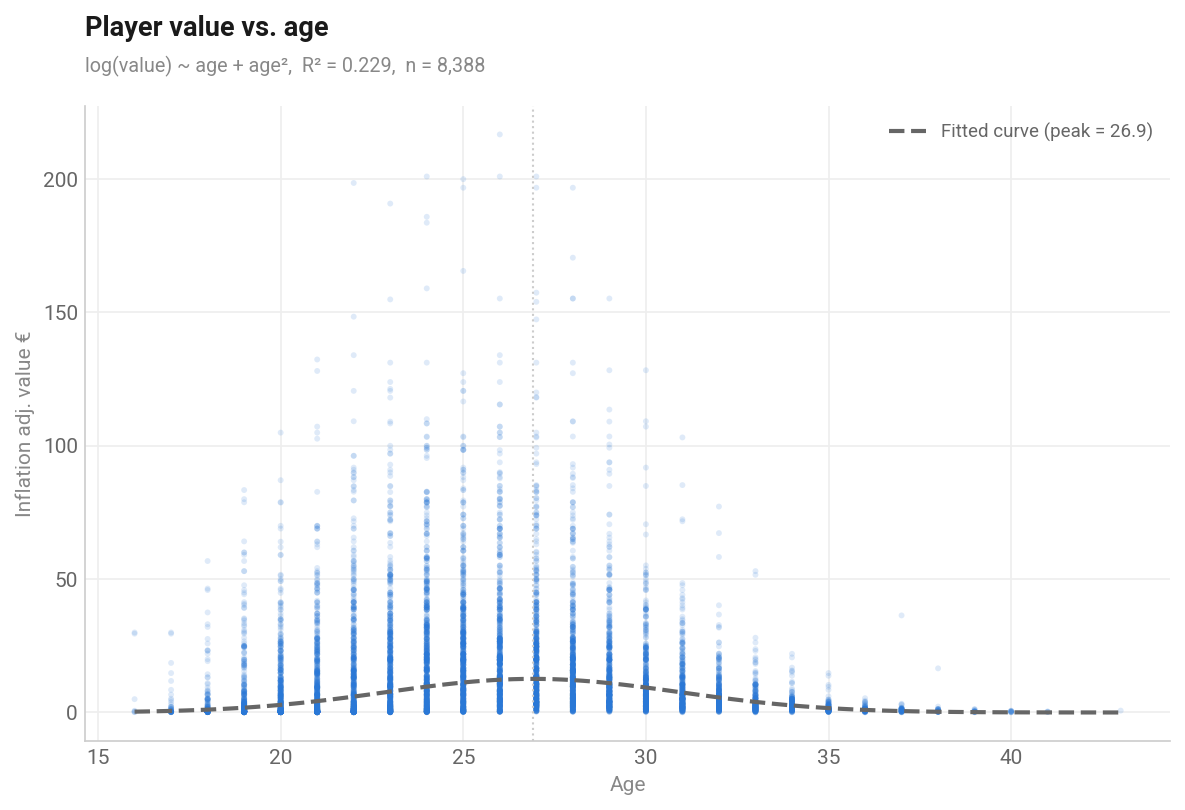

In [28]:
# Age-adjusted squad value: reuses the age-curve fit already built in
# adjust_squad_value_for_age.py rather than re-deriving it. Rationale (see
# that script's docstring): transfer value prices ability *and* resale
# potential, and resale potential is heavily age-weighted, so part of a
# squad's raw value is just "this squad happens to be young", not quality.
# Fitting log(value) ~ age + age^2 and rebasing every player to the curve's
# peak age (holding their age-curve residual -- the actual quality signal --
# fixed) should strip that out and leave a cleaner value->performance signal.
from adjust_squad_value_for_age import fit_age_curve

age_df = player_values.copy()
age_df['value_2025_26_terms'] = age_df['value_real']  # already CPI-adjusted above
age_df['age_sq'] = age_df['age'] ** 2

age_model, peak_age = fit_age_curve(age_df)
print(f'log(value) ~ age + age^2   n={len(age_df)}  R^2={age_model.rsquared:.3f}  peak age={peak_age:.1f}')
for name, coef, se, p in zip(age_model.params.index, age_model.params, age_model.bse, age_model.pvalues):
    print(f'  {name:>8}: {coef: .4f}  (se={se:.4f}, p={p:.3f})')

pred_log_value = age_model.predict(sm.add_constant(age_df[['age', 'age_sq']]))
peak_row = sm.add_constant(pd.DataFrame({'age': [peak_age], 'age_sq': [peak_age ** 2]}), has_constant='add')
pred_log_peak = age_model.predict(peak_row)[0]
# rebase to peak age: value * (curve at peak / curve at this age) -- keeps the
# age-curve residual (this player vs typical-for-age) fixed
age_df['age_adjusted_value'] = age_df['value_2025_26_terms'] * np.exp(pred_log_peak - pred_log_value)

squad_age_adj = age_df.groupby(['season', 'team']).agg(
    squad_value_age_adjusted=('age_adjusted_value', 'sum'),
).reset_index()

panel = panel.merge(squad_age_adj, on=['season', 'team'], how='left')
print(f'\nMerged squad_value_age_adjusted into panel ({panel["squad_value_age_adjusted"].notna().sum()} team-seasons)')

# Age curve chart: raw player values vs age, with the fitted curve overlaid
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(age_df['age'], age_df['value_2025_26_terms'] / 1e6, s=8, alpha=0.15, color=C_XG, edgecolors='none', zorder=2)
age_range = np.linspace(age_df['age'].min(), age_df['age'].max(), 100)
curve_pred = age_model.predict(sm.add_constant(pd.DataFrame({'age': age_range, 'age_sq': age_range ** 2}), has_constant='add'))
ax.plot(age_range, np.exp(curve_pred) / 1e6, '--', color=C_INK2, lw=2, zorder=3, label=f'Fitted curve (peak = {peak_age:.1f})')
ax.axvline(peak_age, color=C_AXIS, lw=1, linestyle=':')
_dw_title(ax, 'Player value vs. age', f'log(value) ~ age + age²,  R² = {age_model.rsquared:.3f},  n = {len(age_df):,}', y=1.1, dy=0.055)
ax.set_xlabel('Age', fontsize=10, color=C_MUTED)
ax.set_ylabel(f'Inflation adj. value €', fontsize=10, color=C_MUTED)
ax.legend(fontsize=9, frameon=False, loc='upper right', labelcolor=C_INK2)
_dw_style(ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'player_value_age_curve.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


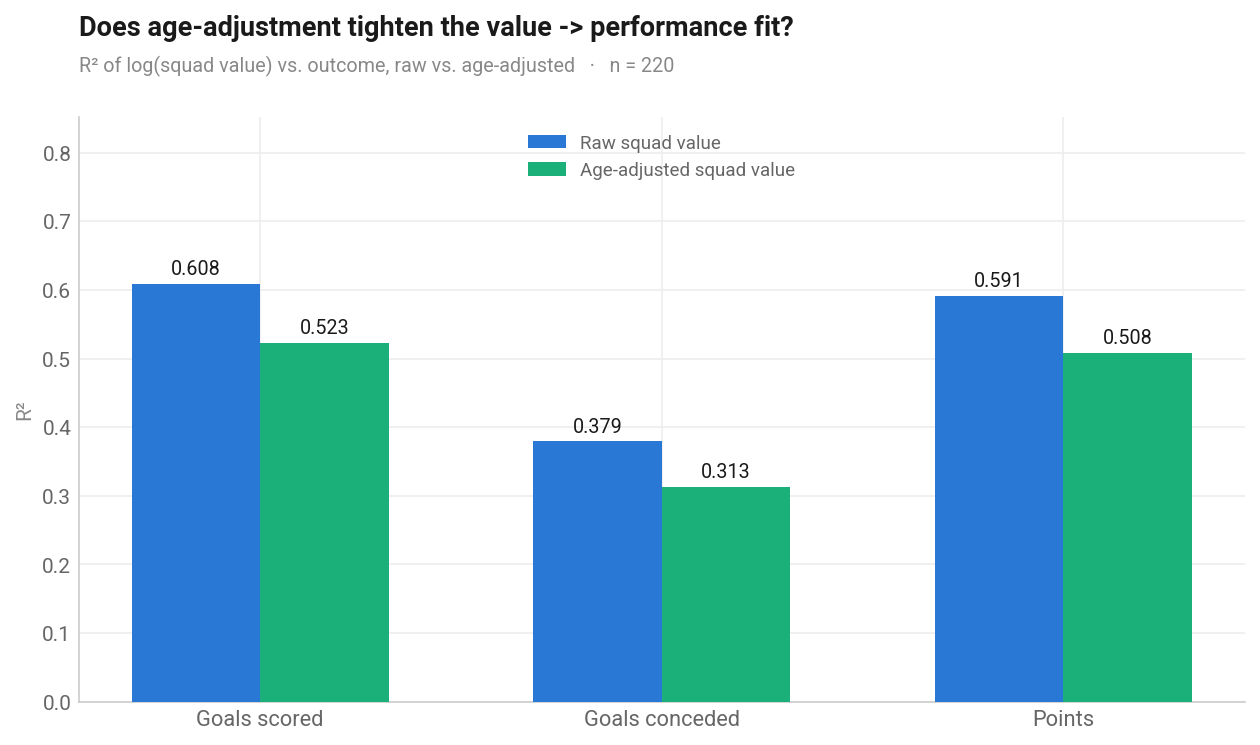

Outcome            R² raw   R² age-adj    delta   verdict
Goals scored        0.608        0.523   -0.086   looser
Goals conceded      0.379        0.313   -0.066   looser
Points              0.591        0.508   -0.083   looser


In [29]:
# Does age-adjustment tighten the value -> performance fit, as hypothesised?
age_reg_df = panel.dropna(subset=['points', 'squad_value_age_adjusted']).copy()
age_reg_df['log_value_raw']     = np.log(age_reg_df['squad_value_real'])
age_reg_df['log_value_adj']     = np.log(age_reg_df['squad_value_age_adjusted'])

outcomes = ['goals_scored', 'goals_conceded', 'points']
labels   = ['Goals scored', 'Goals conceded', 'Points']
r2_raw, r2_adj = [], []
for y_col in outcomes:
    y = age_reg_df[y_col]
    r2_raw.append(sm.OLS(y, sm.add_constant(age_reg_df['log_value_raw'])).fit().rsquared)
    r2_adj.append(sm.OLS(y, sm.add_constant(age_reg_df['log_value_adj'])).fit().rsquared)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
x = np.arange(len(outcomes))
w = 0.32
bars_raw = ax.bar(x - w/2, r2_raw, width=w, color=C_XG, label='Raw squad value', zorder=3)
bars_adj = ax.bar(x + w/2, r2_adj, width=w, color=C_PRED, label='Age-adjusted squad value', zorder=3)
for bars in (bars_raw, bars_adj):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008, f'{b.get_height():.3f}',
                ha='center', va='bottom', fontsize=9.5, color=C_INK)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.5)
ax.set_ylabel('R²', fontsize=10, color=C_MUTED)
ax.set_ylim(0, max(r2_raw + r2_adj) * 1.4)
_dw_title(ax, 'Does age-adjustment tighten the value -> performance fit?',
          f'R² of log(squad value) vs. outcome, raw vs. age-adjusted   ·   n = {len(age_reg_df)}', y=1.13, dy=0.06)
ax.legend(fontsize=9, frameon=False, loc='upper center', labelcolor=C_INK2)
_dw_style(ax, grid_axis='y')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / 'age_adjustment_r2_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'{"Outcome":<16} {"R² raw":>8} {"R² age-adj":>12} {"delta":>8}   verdict')
for label, ra, rj in zip(labels, r2_raw, r2_adj):
    delta = rj - ra
    verdict = 'tighter (supports hypothesis)' if delta > 0.005 else ('looser' if delta < -0.005 else 'no meaningful change')
    print(f'{label:<16} {ra:>8.3f} {rj:>12.3f} {delta:>+8.3f}   {verdict}')


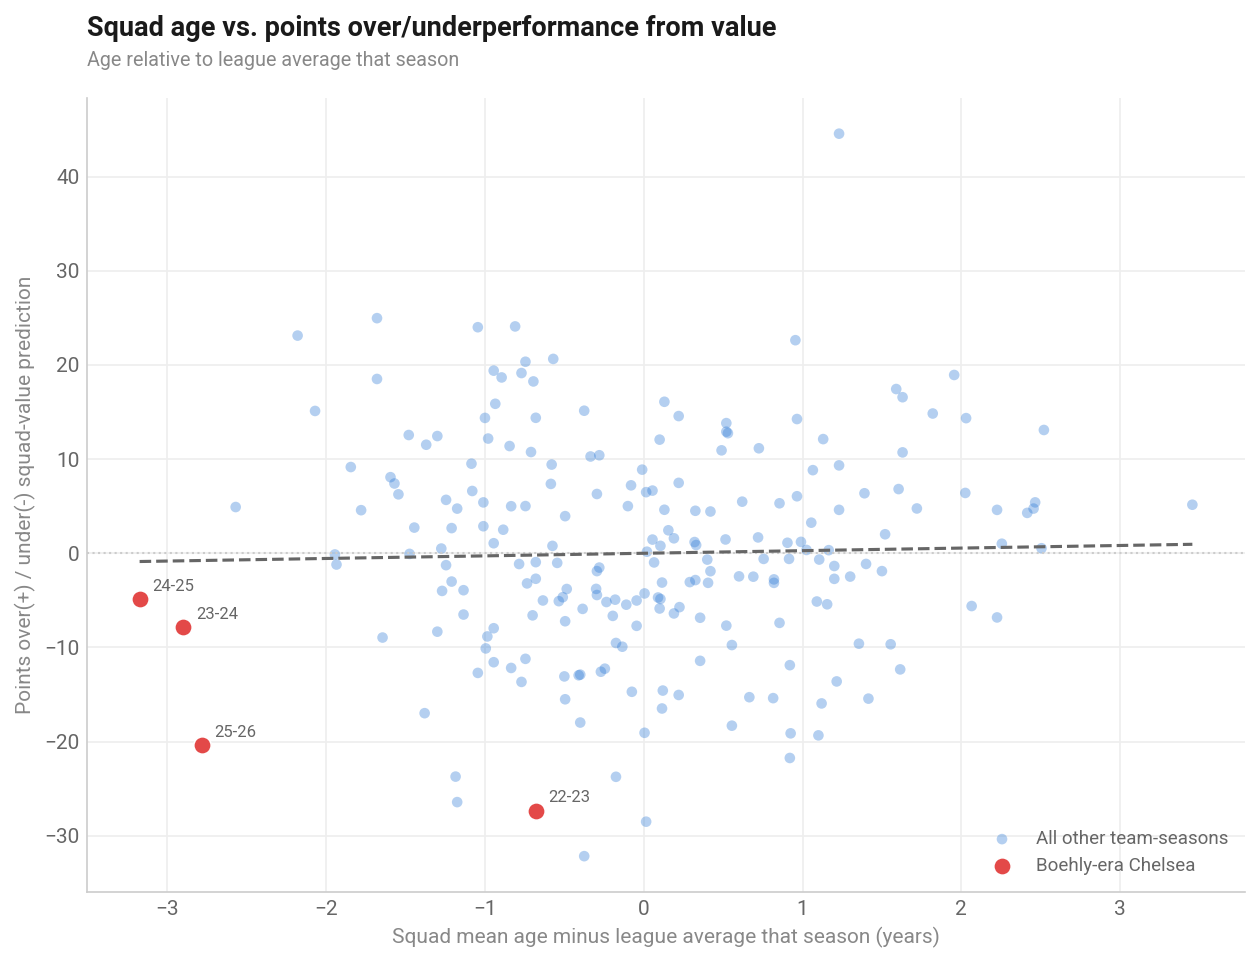

League-wide: age_vs_league vs. points residual -> r=+0.027, p=0.689 (not significant)

   season  mean_age  age_vs_league  points  pred_points  resid_points
2022-2023      24.9         -0.680    44.0    71.317609    -27.317609
2023-2024      22.2         -2.900    63.0    70.853081     -7.853081
2024-2025      22.4         -3.175    69.0    73.881729     -4.881729
2025-2026      22.6         -2.785    52.0    72.384365    -20.384365


In [30]:
# Chelsea case study: is a *specific* young squad's value overstated relative
# to points, even though age-adjusting the whole league loosened the fit?
# Two different questions -- rebasing every player to peak-age (previous two
# cells) inflates youth value if anything (young players are typically priced
# *below* peak-age players of equal ability, so "what would they be worth at
# peak" pushes value up, not down). The direct test of the hypothesis is
# simpler: does a team's raw-value residual (actual points minus what its
# squad value predicts) correlate with how young it is relative to its own
# season's league average?
from scipy.stats import pearsonr


resid_df = panel.dropna(subset=['points']).copy()

#resid_df = resid_df[resid_df['season'].str[:4].astype(int) > 2020]

resid_df['log_raw'] = np.log(resid_df['squad_value_real'])
m_raw = sm.OLS(resid_df['points'], sm.add_constant(resid_df['log_raw'])).fit()
resid_df['pred_points'] = m_raw.predict(sm.add_constant(resid_df['log_raw']))
resid_df['resid_points'] = resid_df['points'] - resid_df['pred_points']
resid_df['age_vs_league'] = resid_df['mean_age'] - resid_df.groupby('season')['mean_age'].transform('mean')

r_all, p_all = pearsonr(resid_df['age_vs_league'], resid_df['resid_points'])

fig, ax = plt.subplots(figsize=(8.5, 6.5))
# Boehly-Clearlake takeover completed May 2022 -- 2022-2023 was their first
# full season of squad-building, so that's the highlight cutoff rather than
# all-time Chelsea.
is_chelsea = (resid_df['team'] == 'Chelsea') & (resid_df['season'].str[:4].astype(int) >= 2022)
ax.scatter(resid_df.loc[~is_chelsea, 'age_vs_league'], resid_df.loc[~is_chelsea, 'resid_points'],
           s=26, alpha=0.35, color=C_XG, edgecolors='none', zorder=2, label='All other team-seasons')
ax.scatter(resid_df.loc[is_chelsea, 'age_vs_league'], resid_df.loc[is_chelsea, 'resid_points'],
           s=70, color=C_OVER, edgecolors='white', linewidths=0.8, zorder=4, label='Boehly-era Chelsea')
for _, row in resid_df[is_chelsea].iterrows():
    ax.annotate(row['season'][2:4] + '-' + row['season'][7:9], (row['age_vs_league'], row['resid_points']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color=C_INK2)

xs = np.linspace(resid_df['age_vs_league'].min(), resid_df['age_vs_league'].max(), 100)
trend = sm.OLS(resid_df['resid_points'], sm.add_constant(resid_df['age_vs_league'])).fit()
ax.plot(xs, trend.predict(sm.add_constant(xs, has_constant='add')), '--', color=C_INK2, lw=1.5, zorder=3)
ax.axhline(0, color=C_AXIS, lw=1, linestyle=':')

_dw_title(ax, 'Squad age vs. points over/underperformance from value',
          f'Age relative to league average that season',
          y=1.07, dy=0.035)
ax.set_xlabel('Squad mean age minus league average that season (years)', fontsize=10, color=C_MUTED)
ax.set_ylabel('Points over(+) / under(-) squad-value prediction', fontsize=10, color=C_MUTED)
ax.legend(fontsize=9, frameon=False, loc='lower right', labelcolor=C_INK2)
_dw_style(ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'chelsea_age_value_residual.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f'League-wide: age_vs_league vs. points residual -> r={r_all:+.3f}, p={p_all:.3f} '
      f'({"significant" if p_all < 0.05 else "not significant"})')
print()
print(resid_df.loc[is_chelsea, ['season', 'mean_age', 'age_vs_league', 'points', 'pred_points', 'resid_points']]
      .sort_values('season').to_string(index=False))


In [31]:
# Is a team fixed effect worth adding to the value -> points regression?
# Compares value-only vs. value + team-dummy models: raw R^2 will mechanically
# rise with 33 extra parameters regardless of real signal, so the real
# questions are (a) is the joint improvement statistically significant
# (nested F-test), and (b) do complexity-penalised criteria (AIC/BIC) still
# prefer the bigger model once that penalty is applied.
from statsmodels.stats.anova import anova_lm

fe_df = panel.dropna(subset=['points']).copy()
fe_df['log_value'] = np.log(fe_df['squad_value_real'])

m_restricted = sm.OLS(fe_df['points'], sm.add_constant(fe_df[['log_value']])).fit()
team_dummies = pd.get_dummies(fe_df['team'], drop_first=True).astype(float)
X_full = sm.add_constant(pd.concat([fe_df[['log_value']], team_dummies], axis=1))
m_full = sm.OLS(fe_df['points'], X_full).fit()

anova_res = anova_lm(m_restricted, m_full)
f_stat, f_pval = anova_res['F'].iloc[1], anova_res['Pr(>F)'].iloc[1]

print(f'{"Model":<24} {"R²":>8} {"adj R²":>8} {"AIC":>10} {"BIC":>10}  params')
print(f'{"Value only":<24} {m_restricted.rsquared:>8.4f} {m_restricted.rsquared_adj:>8.4f} '
      f'{m_restricted.aic:>10.1f} {m_restricted.bic:>10.1f}  {int(m_restricted.df_model)+1}')
print(f'{"Value + team FE":<24} {m_full.rsquared:>8.4f} {m_full.rsquared_adj:>8.4f} '
      f'{m_full.aic:>10.1f} {m_full.bic:>10.1f}  {int(m_full.df_model)+1}')
print(f'\nNested F-test on the 33 team dummies: F={f_stat:.3f}, p={f_pval:.4f} '
      f'({"jointly significant at 5%" if f_pval < 0.05 else "not jointly significant"})')

seasons_per_team = fe_df.groupby('team').size().sort_values()
print(f'\nSeasons-in-sample per team: min={seasons_per_team.min()} (e.g. '
      f'{", ".join(seasons_per_team[seasons_per_team == seasons_per_team.min()].index[:5])}), '
      f'max={seasons_per_team.max()}, median={seasons_per_team.median():.0f}')
print('AIC/BIC verdict:', 'AIC prefers team FE' if m_full.aic < m_restricted.aic else 'AIC prefers value-only',
      '  |  ', 'BIC prefers team FE' if m_full.bic < m_restricted.bic else 'BIC prefers value-only')


Model                          R²   adj R²        AIC        BIC  params
Value only                 0.5909   0.5890     1703.7     1710.5  2
Value + team FE            0.6815   0.6229     1714.6     1833.4  35

Nested F-test on the 33 team dummies: F=1.594, p=0.0290 (jointly significant at 5%)

Seasons-in-sample per team: min=1 (e.g. Hull, Ipswich, Middlesbrough, Cardiff, Luton), max=11, median=7
AIC/BIC verdict: AIC prefers value-only   |   BIC prefers value-only


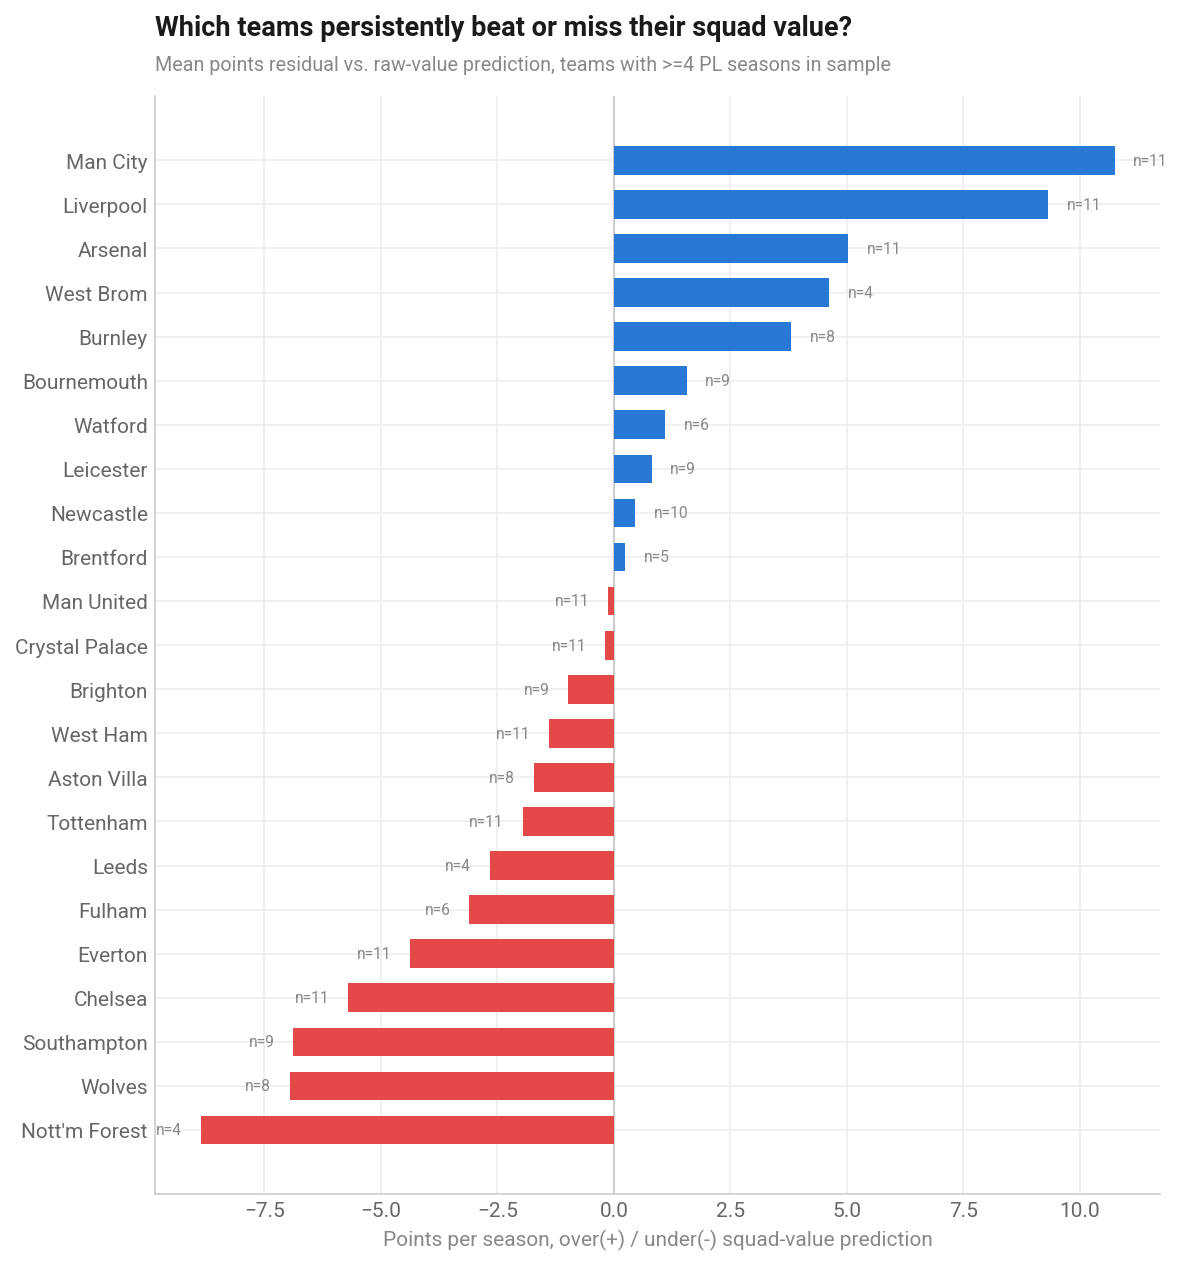

In [32]:
# Even if team FE isn't worth baking into the regression, "which teams
# persistently over/underperform their squad value" is still a useful
# diagnostic. Restricted to teams with >=4 seasons in-sample -- below that a
# team's average residual is just fitting 1-3 data points, not a real signal.
MIN_SEASONS = 4
team_resid = (
    resid_df.groupby('team')
    .agg(n_seasons=('season', 'size'), mean_resid=('resid_points', 'mean'), std_resid=('resid_points', 'std'))
    .query('n_seasons >= @MIN_SEASONS')
    .sort_values('mean_resid')
)

fig, ax = plt.subplots(figsize=(8, 8.5))
colors = [C_OVER if v < 0 else C_UNDER for v in team_resid['mean_resid']]
ax.barh(team_resid.index, team_resid['mean_resid'], color=colors, height=0.65, zorder=3)
ax.axvline(0, color=C_AXIS, lw=1)
for team, row in team_resid.iterrows():
    ax.text(row['mean_resid'] + (0.4 if row['mean_resid'] >= 0 else -0.4), team, f'n={row["n_seasons"]:.0f}',
            va='center', ha='left' if row['mean_resid'] >= 0 else 'right', fontsize=7.5, color=C_MUTED)

_dw_title(ax, 'Which teams persistently beat or miss their squad value?',
          'Mean points residual vs. raw-value prediction, teams with >=4 PL seasons in sample', y=1.05, dy=0.03)
ax.set_xlabel('Points per season, over(+) / under(-) squad-value prediction', fontsize=10, color=C_MUTED)
_dw_style(ax, grid_axis='x')
plt.tight_layout()
plt.savefig(OUT_DIR / 'team_value_residual_ranking.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [33]:
# Position-group squad values: sum each team-season's player values within
# Defence / Midfield / Attack. `position` was added to
# infra/data/collectors/transfermarkt/pull_transfermarkt_values.py this
# session and all 240 team-seasons were freshly re-scraped to backfill it
# (name/age/value are unchanged from before -- only position is new).
# Grouping is a judgment call, not a fact: goalkeepers are folded into
# Defence (common convention, though their value dynamics differ a lot from
# outfield defenders -- fewer, less liquid transfers), and wingers are
# folded into Attack (treated as wide forwards) rather than Midfield.
POSITION_GROUP = {
    'Goalkeeper': 'Defence',
    'Centre-Back': 'Defence',
    'Left-Back': 'Defence',
    'Right-Back': 'Defence',
    'Sweeper': 'Defence',
    'Defender': 'Defence',
    'Defensive Midfield': 'Midfield',
    'Central Midfield': 'Midfield',
    'Attacking Midfield': 'Midfield',
    'Left Midfield': 'Midfield',
    'Right Midfield': 'Midfield',
    'Midfielder': 'Midfield',
    'Left Winger': 'Attack',
    'Right Winger': 'Attack',
    'Second Striker': 'Attack',
    'Centre-Forward': 'Attack',
    'Forward': 'Attack',
}

unmapped = set(player_values['position'].dropna().unique()) - set(POSITION_GROUP)
assert not unmapped, f"Unmapped positions found, extend POSITION_GROUP: {unmapped}"

player_values['position_group'] = player_values['position'].map(POSITION_GROUP)

group_values = (
    player_values.groupby(['season', 'team', 'position_group'])['value_real']
    .sum()
    .unstack('position_group')
    .rename(columns={'Defence': 'value_defence', 'Midfield': 'value_midfield', 'Attack': 'value_attack'})
    .reset_index()
)

panel = panel.merge(group_values, on=['season', 'team'], how='left')
n_complete = panel[['value_defence', 'value_midfield', 'value_attack']].notna().all(axis=1).sum()
print(f'Position-group values merged: {n_complete} / {len(panel)} team-seasons complete')

# sanity check: group values should sum close to squad_value_real (won't be
# exact if any player-season slipped through with a null/unmapped position,
# but the assert above already rules that out for this run)
check = panel[['squad_value_real', 'value_defence', 'value_midfield', 'value_attack']].dropna()
check_sum = check['value_defence'] + check['value_midfield'] + check['value_attack']
max_gap_pct = ((check_sum - check['squad_value_real']).abs() / check['squad_value_real']).max() * 100
print(f'Max gap between group-value sum and squad_value_real: {max_gap_pct:.3f}% (should be ~0)')

panel[['team', 'season', 'value_defence', 'value_midfield', 'value_attack']].head(10)


Position-group values merged: 240 / 240 team-seasons complete
Max gap between group-value sum and squad_value_real: 0.000% (should be ~0)


,team,season,value_defence,value_midfield,value_attack
0,Arsenal,2015-2016,2.031448e+08,2.442641e+08,1.940383e+08
1,Aston Villa,2015-2016,6.367538e+07,4.973545e+07,5.183694e+07
2,Bournemouth,2015-2016,3.194277e+07,1.800283e+07,9.001415e+07
3,Chelsea,2015-2016,2.017438e+08,2.465757e+08,3.271332e+08
4,Crystal Palace,2015-2016,4.917505e+07,6.199418e+07,7.894627e+07
5,Everton,2015-2016,1.297325e+08,8.616141e+07,1.341456e+08
6,Leicester,2015-2016,5.323794e+07,6.934943e+07,1.031135e+08
7,Liverpool,2015-2016,1.967702e+08,1.630062e+08,1.659483e+08
8,Man City,2015-2016,2.134421e+08,2.928087e+08,1.933378e+08
9,Man United,2015-2016,2.553320e+08,1.843714e+08,1.765258e+08


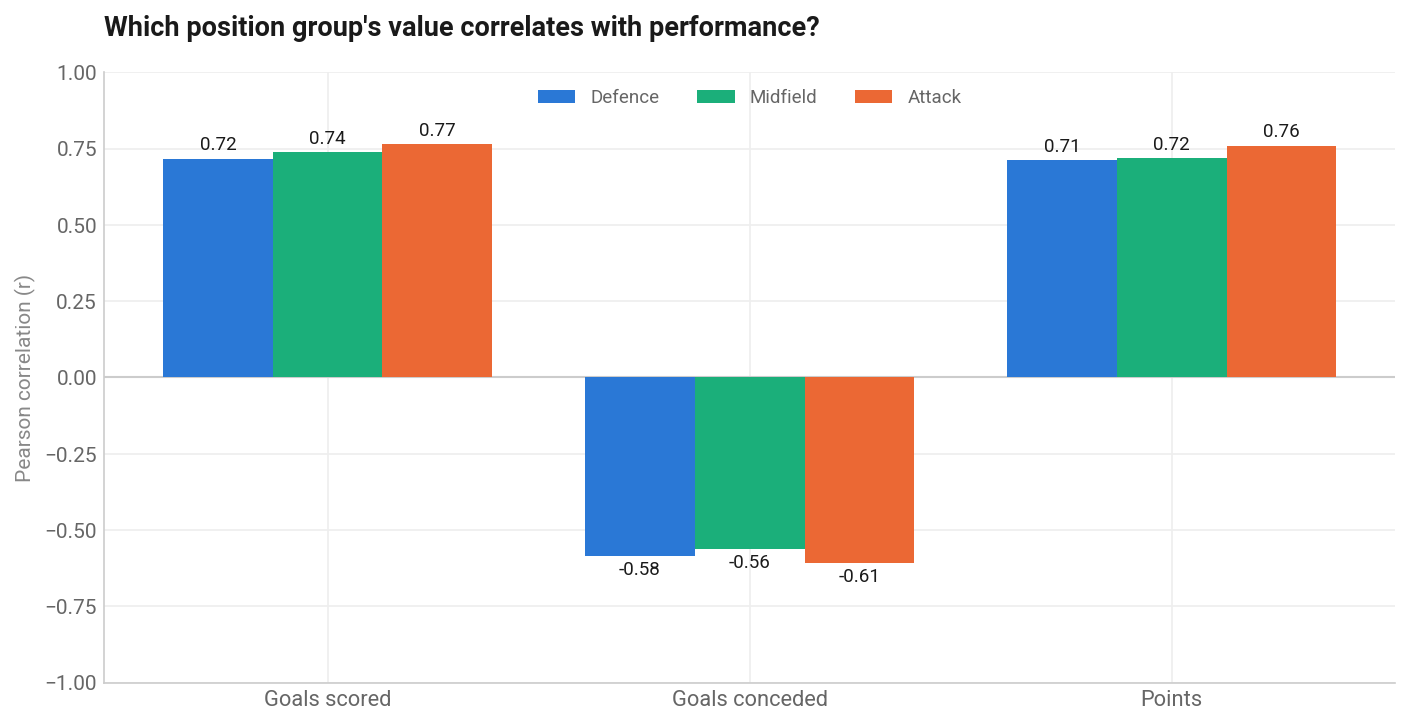

          Goals scored  Goals conceded  Points
Defence          0.717          -0.584   0.713
Midfield         0.739          -0.562   0.718
Attack           0.765          -0.607   0.760


In [45]:
# Grouped bar chart instead of a heatmap: a 3x3 grid of numbers close in
# magnitude doesn't need a colour-coded matrix to scan -- signed bars show
# the same r values (correctly preserving the negative sign on goals
# conceded) in a format that's faster to compare at a glance.
posgrp_df = panel.dropna(subset=['points', 'value_defence', 'value_midfield', 'value_attack']).copy()
for col in ['value_defence', 'value_midfield', 'value_attack']:
    posgrp_df[f'log_{col}'] = np.log(posgrp_df[col])

GROUP_COLS   = ['log_value_defence', 'log_value_midfield', 'log_value_attack']
GROUP_LABELS = ['Defence', 'Midfield', 'Attack']
GROUP_COLORS = [C_XG, C_PRED, C_GOALS]
OUTCOME_COLS   = ['goals_scored', 'goals_conceded', 'points']
OUTCOME_LABELS = ['Goals scored', 'Goals conceded', 'Points']
OUTCOMES = list(zip(OUTCOME_COLS, OUTCOME_LABELS))

r_table = pd.DataFrame(index=GROUP_LABELS, columns=OUTCOME_LABELS, dtype=float)
for group_col, group_label in zip(GROUP_COLS, GROUP_LABELS):
    for y_col, y_label in OUTCOMES:
        r_table.loc[group_label, y_label] = np.corrcoef(posgrp_df[group_col], posgrp_df[y_col])[0, 1]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(OUTCOME_LABELS))
w = 0.26
for i, (group_label, color) in enumerate(zip(GROUP_LABELS, GROUP_COLORS)):
    vals = r_table.loc[group_label].values
    bars = ax.bar(x + (i - 1) * w, vals, width=w, color=color, label=group_label, zorder=3)
    for b, v in zip(bars, vals):
        va = 'bottom' if v >= 0 else 'top'
        offset = 0.015 if v >= 0 else -0.015
        ax.text(b.get_x() + b.get_width() / 2, v + offset, f'{v:.2f}', ha='center', va=va, fontsize=9, color=C_INK)

ax.axhline(0, color=C_AXIS, lw=1)
ax.set_xticks(x)
ax.set_xticklabels(OUTCOME_LABELS, fontsize=10.5)
ax.set_ylabel('Pearson correlation (r)', fontsize=10, color=C_MUTED)
ax.set_ylim(-1, 1)
_dw_title(ax, 'Which position group\'s value correlates with performance?',
          y=1.05, dy=0.06)
ax.legend(fontsize=9, frameon=False, loc='upper center', ncol=3, labelcolor=C_INK2)
_dw_style(ax, grid_axis='y')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig(OUT_DIR / 'position_group_value_corr.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(r_table.round(3))


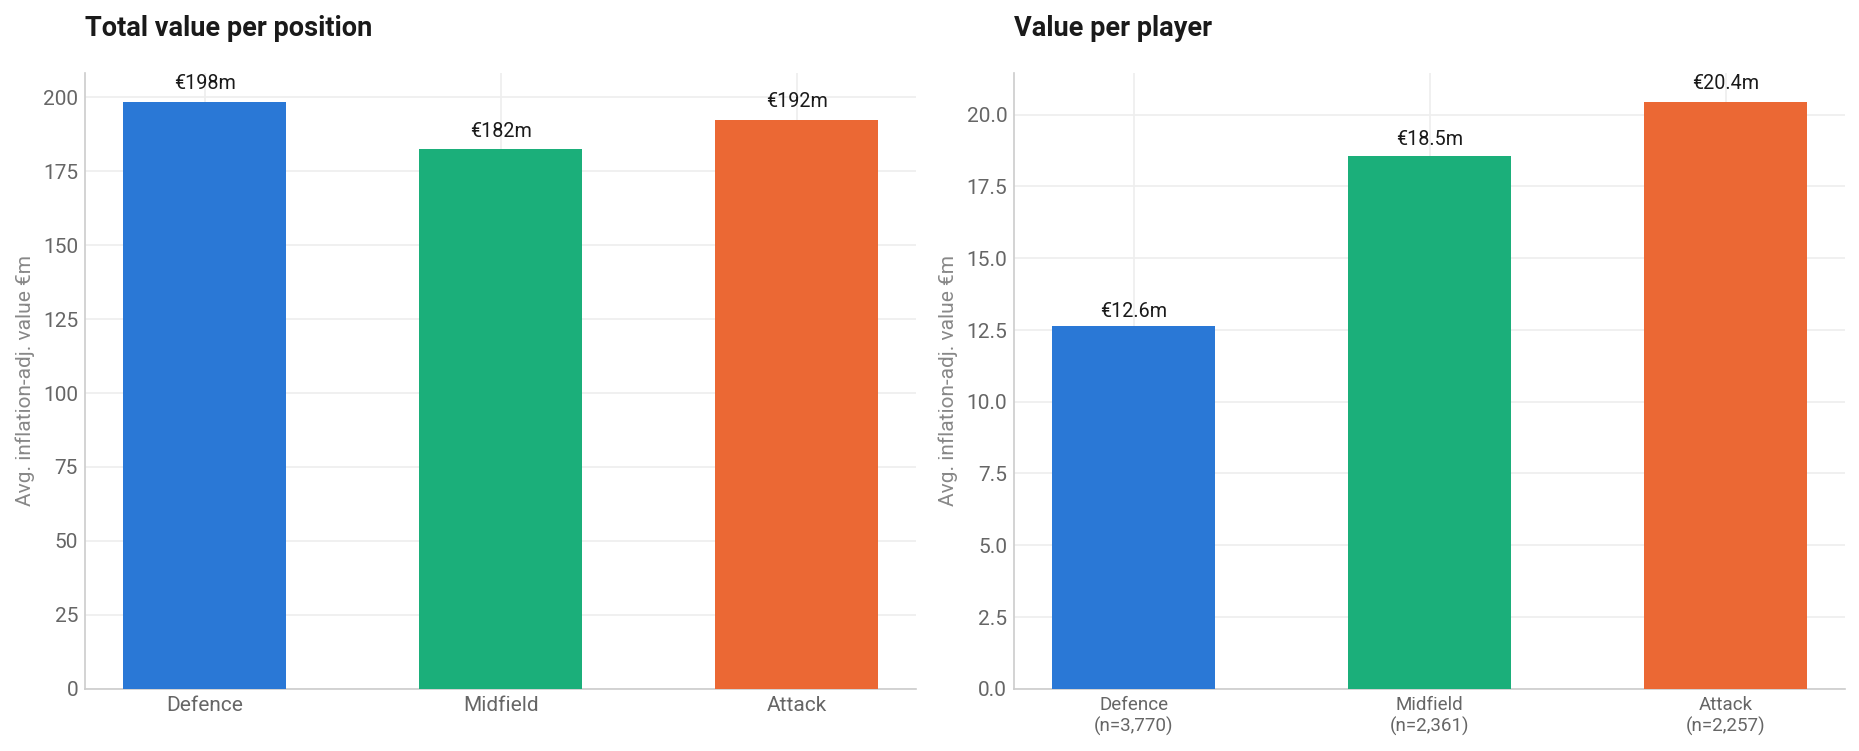

Average total value per squad, by line:
Defence     198.3
Midfield    182.4
Attack      192.3
dtype: float64

Average value per player, by position group:
                mean_m  size
position_group              
Defence          12.63  3770
Midfield         18.54  2361
Attack           20.45  2257


In [44]:
# Average value per position group -- context for the correlation chart above.
# Two panels rather than one: squads carry noticeably more defenders than
# midfielders or attackers (~15.7 vs ~9.8 vs ~9.4 average per squad), so a
# total-value-per-group chart alone conflates "this line gets more total
# investment" with "this line just has more players." The per-player panel
# separates those two effects.
group_totals_df = panel.dropna(subset=['value_defence', 'value_midfield', 'value_attack'])
avg_group_total = group_totals_df[['value_defence', 'value_midfield', 'value_attack']].mean()
avg_group_total.index = GROUP_LABELS

per_player = player_values.dropna(subset=['position_group']).groupby('position_group')['value_real'].agg(['mean', 'size'])
per_player = per_player.loc[GROUP_LABELS]
per_player_xticks = [f'{g}\n(n={n:,})' for g, n in zip(GROUP_LABELS, per_player['size'])]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))

bars0 = axes[0].bar(GROUP_LABELS, avg_group_total.values / 1e6, color=GROUP_COLORS, width=0.55, zorder=3)
for b, v in zip(bars0, avg_group_total.values / 1e6):
    axes[0].text(b.get_x() + b.get_width() / 2, v + v * 0.015, f'€{v:.0f}m', ha='center', va='bottom', fontsize=9.5, color=C_INK)
_dw_title(axes[0], 'Total value per position', y=1.05, dy=0.06)
axes[0].set_ylabel('Avg. inflation-adj. value €m', fontsize=10, color=C_MUTED)
_dw_style(axes[0], grid_axis='y')

bars1 = axes[1].bar(per_player_xticks, per_player['mean'].values / 1e6, color=GROUP_COLORS, width=0.55, zorder=3)
for b, v in zip(bars1, per_player['mean'].values / 1e6):
    axes[1].text(b.get_x() + b.get_width() / 2, v + v * 0.015, f'€{v:.1f}m', ha='center', va='bottom', fontsize=9.5, color=C_INK)
_dw_title(axes[1], 'Value per player', y=1.05, dy=0.06)
axes[1].set_ylabel('Avg. inflation-adj. value €m', fontsize=10, color=C_MUTED)
axes[1].tick_params(axis='x', labelsize=9)
_dw_style(axes[1], grid_axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / 'position_group_avg_value.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('Average total value per squad, by line:')
print((avg_group_total / 1e6).round(1))
print('\nAverage value per player, by position group:')
print(per_player.assign(mean_m=lambda d: (d['mean'] / 1e6).round(2))[['mean_m', 'size']])


In [36]:
# Multivariate: does each group have independent predictive power once the
# others are controlled for? Position-group values are expected to be highly
# collinear (rich clubs spend across every line, not just one), so check VIF
# before trusting any individual coefficient's sign/significance.
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_cols = ['log_value_defence', 'log_value_midfield', 'log_value_attack']
X = sm.add_constant(posgrp_df[X_cols])

vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])], index=X_cols)
print('VIF (variance inflation factor -- >5 is usually flagged, >10 is severe):')
print(vif.round(2).to_string())
print()

for y_col, y_label in OUTCOMES:
    model = sm.OLS(posgrp_df[y_col], X).fit()
    print(f'=== {y_label} ~ log(defence) + log(midfield) + log(attack)   R²={model.rsquared:.3f}  n={len(posgrp_df)} ===')
    for name, coef, se, p in zip(model.params.index, model.params, model.bse, model.pvalues):
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  {name:>22}: {coef: 7.3f}  (se={se:.3f}, p={p:.3f}) {sig}')
    print()


VIF (variance inflation factor -- >5 is usually flagged, >10 is severe):
log_value_defence     5.98
log_value_midfield    5.20
log_value_attack      3.92

=== Goals scored ~ log(defence) + log(midfield) + log(attack)   R²=0.622  n=220 ===
                   const: -348.947  (se=21.725, p=0.000) ***
       log_value_defence:   0.527  (se=2.627, p=0.841) 
      log_value_midfield:   7.868  (se=2.314, p=0.001) ***
        log_value_attack:  12.977  (se=2.236, p=0.000) ***

=== Goals conceded ~ log(defence) + log(midfield) + log(attack)   R²=0.387  n=220 ===
                   const:  309.832  (se=22.006, p=0.000) ***
       log_value_defence:  -3.990  (se=2.661, p=0.135) 
      log_value_midfield:  -1.472  (se=2.344, p=0.531) 
        log_value_attack:  -8.121  (se=2.265, p=0.000) ***

=== Points ~ log(defence) + log(midfield) + log(attack)   R²=0.604  n=220 ===
                   const: -366.641  (se=23.309, p=0.000) ***
       log_value_defence:   2.195  (se=2.819, p=0.437) 
      log_v